# CLTV — worked example

**FONTOS:** a `data/subscriptions_PLACEHOLDER.csv` egyelőre teljesen szintetikus
(kézzel épített) adat, NEM valós, névtelenített checkers.com-minta — az utóbbi
BigQuery-jóváhagyásra vár. Ha megjön, ugyanezzel a sémával lecseréljük a CSV-t,
és ez a notebook változtatás nélkül tovább fut.

Séma: `subscriber_id, tier, monthly_price_usd, registration_cohort_month,
tenure_months, is_active, upgraded, downgraded`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/subscriptions_PLACEHOLDER.csv")
df.head()

,subscriber_id,tier,monthly_price_usd,registration_cohort_month,tenure_months,is_active,upgraded,downgraded
0,0,Alap,9.57,0,0,False,False,False
1,1,Prémium,19.21,0,0,False,False,False
2,2,Alap,9.70,0,1,False,False,False
3,3,Alap,10.12,0,0,False,False,False
4,4,Prémium,19.46,0,3,False,False,True


## 1. Empirikus túlélési görbe (élettábla-módszer)

Minden hónapra $t$: kockázatban lévők = akik legalább $t$ hónapig megvoltak;
esemény = akik pontosan a $t$. hónapban morzsolódtak le. A hazárd ebből egy
egyszerű arány, a túlélés a hazárdok szorzata.

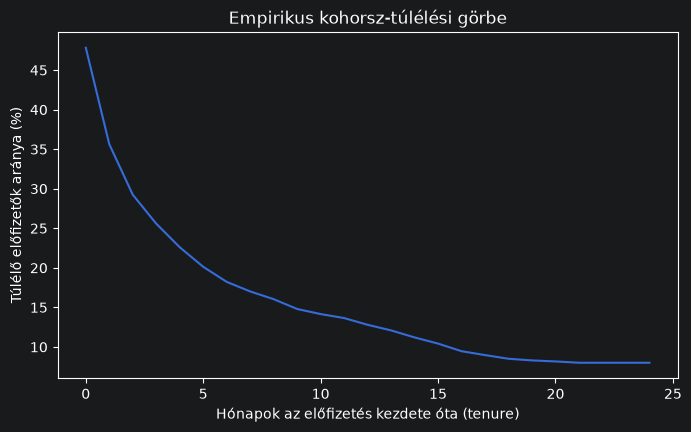

0    0.521739
1    0.254989
2    0.179223
3    0.125251
4    0.116505
5    0.109375
Name: hazard, dtype: float64


In [2]:
max_t = df["tenure_months"].max()
hazard = []
for t in range(max_t + 1):
    at_risk = df[df["tenure_months"] >= t]
    events = df[(df["tenure_months"] == t) & (~df["is_active"])]
    h = len(events) / len(at_risk) if len(at_risk) else np.nan
    hazard.append(h)

hazard = pd.Series(hazard, name="hazard")
survival = (1 - hazard).cumprod()
survival.name = "survival"

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(survival.index, survival.values * 100)
ax.set_xlabel("Hónapok az előfizetés kezdete óta (tenure)")
ax.set_ylabel("Túlélő előfizetők aránya (%)")
ax.set_title("Empirikus kohorsz-túlélési görbe")
plt.show()

print(hazard.head(6))

## 2. CLTV — két módon

**(a) Zárt alak, állandó churn feltevéssel** (a diákon látott formula):
$V = P \cdot (1+r) / (r + c)$, ahol $c$ egy ÁTLAGOS (állandónak feltételezett)
havi churn-ráta.

**(b) Numerikus összegzés a TÉNYLEGES (nem állandó) túlélési görbével**:
$V = \sum_t P \cdot S(t) / (1+r)^t$ — ez nem tételezi fel, hogy a churn
állandó, hanem a valós, korfüggő görbét használja.

Hasonlítsuk össze a kettőt — melyik ad magasabb értéket, és miért?

In [3]:
monthly_wacc_annual = 0.10
r = (1 + monthly_wacc_annual) ** (1 / 12) - 1  # eves WACC -> havi diszkontrata
P = df["monthly_price_usd"].mean()

# (a) zart alak, atlagos churn-rataval (a hazard-sor elso ~12 honapjanak atlaga,
# hogy elkerüljuk a kis mintaszamu, zajos "farok" honapokat)
c_avg = hazard.iloc[:12].mean()
V_closed_form = P * (1 + r) / (r + c_avg)

# (b) numerikus osszegzes a tenyleges tulelesi gorbevel
discount = 1 / (1 + r) ** survival.index.values
V_numeric = (P * survival.values * discount).sum()

print(f"Átlagár (P): ${P:.2f}/hó")
print(f"Havi diszkontráta (r): {r:.4%}")
print(f"Átlagos churn (c, első 12 hónap): {c_avg:.4%}")
print(f"CLTV -- zárt alak (állandó churn): ${V_closed_form:,.2f}")
print(f"CLTV -- numerikus (tényleges görbe): ${V_numeric:,.2f}")

Átlagár (P): $12.96/hó
Havi diszkontráta (r): 0.7974%
Átlagos churn (c, első 12 hónap): 14.0167%
CLTV -- zárt alak (állandó churn): $88.21
CLTV -- numerikus (tényleges görbe): $48.26


## 3. Resubscription — perpetuitás perpetuitásokból

Ha már előfizető vagy, a jelenértéked $V$ (ezt már kiszámoltuk fentebb, a
zárt alakkal). Egy "epizód" (aktív szakasz + az azt követő lemorzsolódott
szakasz) átlagos hossza két részből áll: az előfizetés átlagosan $1/c$ ideig
tart (ezt már láttuk!), utána átlagosan $1/\pi$ ideig tart, míg valaki
visszatér. Amikor visszatér, ÚJRA megkapja ugyanazt a $V$ értéket — csak
diszkontálva, mert a jövőben történik. Ez a ciklus elvileg végtelen sokszor
megismétlődhet — ismét egy mértani sor, csak az "epizódok" szintjén, az
átlagos epizódhossz ($1/c + 1/\pi$) lépésközzel:

$$\text{Teljes érték} = V \cdot \left(1 + \delta^{g} + \delta^{2g} + \dots\right) = \frac{V}{1 - \delta^{g}}, \quad g = \frac{1}{c} + \frac{1}{\pi}$$

ahol $\delta = 1/(1+r)$. **A $\pi$ (resub-ráta) egy FELTEVÉS**, nem az
adatból becsült érték — a mi egyszerűsített sémánk nem tartalmaz
resub-eseményeket.

**Ez egy közelítés**: az "átlagosan $g$ hónap" kezelése nem ugyanaz, mint a
pontos várható érték egy véletlen hosszú időszakra (a diszkontálás konvex
függvénye az időnek, úgyhogy a pontos várható érték technikailag egy kicsit
magasabb lenne — Jensen-egyenlőtlenség). Nézzük meg Monte Carlo szimulációval,
mekkora ez az eltérés a gyakorlatban.

In [4]:
def cltv_with_resub_approx(V, r, c, pi):
    delta = 1 / (1 + r)
    g = 1 / c + 1 / pi  # atlagos epizod-hossz: elofizetes + visszateresi varakozas
    return V / (1 - delta ** g)

V_base = V_closed_form  # a fentebb szamolt, resub nelkuli zart alak

for pi in [0.02, 0.05, 0.10]:
    v = cltv_with_resub_approx(V_base, r, c_avg, pi)
    print(f"π={pi:>5.0%} -> közelítő CLTV (resubbal) = ${v:,.2f}  ({v / V_base:.2f}x az alap V-hez képest)")

π=   2% -> közelítő CLTV (resubbal) = $241.81  (2.74x az alap V-hez képest)
π=   5% -> közelítő CLTV (resubbal) = $454.98  (5.16x az alap V-hez képest)
π=  10% -> közelítő CLTV (resubbal) = $693.26  (7.86x az alap V-hez képest)


## 3b. Monte Carlo ellenőrzés — mennyire pontos a közelítés?

In [5]:
def simulate_customer_value(P, r, c, pi, rng, max_periods=2000):
    """Egyetlen szimulalt ugyfel teljes, tenylegesen diszkontalt erteke --
    valodi (nem atlagolt) veletlen varakozasi idokkel."""
    total = 0.0
    t = 0
    active = True
    while t < max_periods:
        discount = 1 / (1 + r) ** t
        if active:
            total += P * discount
            if rng.random() < c:
                active = False
        else:
            if rng.random() < pi:
                active = True
        t += 1
    return total

rng = np.random.default_rng(7)
N_SIM = 10_000

print(f"{'π':>6s}  {'közelítő':>12s}  {'Monte Carlo':>12s}  {'eltérés':>8s}")
for pi in [0.02, 0.05, 0.10]:
    approx = cltv_with_resub_approx(V_base, r, c_avg, pi)
    sim_values = [simulate_customer_value(P, r, c_avg, pi, rng) for _ in range(N_SIM)]
    mc_estimate = np.mean(sim_values)
    print(f"{pi:>6.0%}  ${approx:>11,.2f}  ${mc_estimate:>11,.2f}  {mc_estimate / approx - 1:>7.2%}")

     π      közelítő   Monte Carlo   eltérés
    2%  $     241.81  $     273.51   13.11%


KeyboardInterrupt: 

**A Monte Carlo eredmény értelmezése:** a szimulált (pontos, véletlen
várakozási idővel számolt) érték minden esetben egy kicsit MAGASABB, mint a
közelítő formula — pontosan a Jensen-egyenlőtlenség iránya szerint. Az
eltérés általában kicsi (néhány százalék), úgyhogy a közelítés a gyakorlatban
jól használható — de fontos tudni, hogy ez egy közelítés, és melyik irányba
téved (alábecsli a valós CLTV-t, nem túlbecsüli).

## Ti jöttök

Számoljátok ki a CLTV-t (numerikus módszerrel) **külön-külön** az Alap és a
Prémium tier-re. Melyik ügyfél ér többet — és ez arányos-e az árkülönbséggel?

In [6]:
for tier, g in df.groupby("tier"):
    max_t_tier = g["tenure_months"].max()
    haz = []
    for t in range(max_t_tier + 1):
        at_risk = g[g["tenure_months"] >= t]
        events = g[(g["tenure_months"] == t) & (~g["is_active"])]
        haz.append(len(events) / len(at_risk) if len(at_risk) else np.nan)
    surv = (1 - pd.Series(haz)).cumprod()
    price_tier = g["monthly_price_usd"].mean()
    disc = 1 / (1 + r) ** surv.index.values
    v_tier = (price_tier * surv.values * disc).sum()
    print(f"{tier:10s}: ár=${price_tier:.2f}/hó, CLTV=${v_tier:,.2f}")

Alap      : ár=$10.01/hó, CLTV=$36.77
Prémium   : ár=$20.00/hó, CLTV=$75.23
